In [142]:
import pandas as pd
from IPython.display import display
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.metrics import r2_score, f1_score
from sklearn.metrics import precision_score, recall_score
from sklearn.ensemble import BaggingClassifier, BaggingRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import accuracy_score, mean_squared_error
import warnings
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, ExtraTreesClassifier, ExtraTreesRegressor, AdaBoostClassifier, AdaBoostRegressor, GradientBoostingClassifier, GradientBoostingRegressor

In [143]:
df = pd.read_csv('datasets/Sleep_health_and_lifestyle_dataset_processed.csv')
display(df.head(2))

,person_id,gender,age,sleep_duration,quality_of_sleep,physical_activity_level,stress_level,bmi_category,heart_rate,daily_steps,...,occupation_Lawyer,occupation_Manager,occupation_Nurse,occupation_Sales Representative,occupation_Salesperson,occupation_Scientist,occupation_Software Engineer,occupation_Teacher,systolic,diastolic
0,1,1,-1.753096,-1.298887,-1.09828,-0.825418,0.347021,1,1.654719,-1.619584,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.330002,-0.268102
1,2,1,-1.637643,-1.173036,-1.09828,0.039844,1.475592,0,1.170474,1.970077,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.459239,-0.755640


In [144]:
display(df.info)

<bound method DataFrame.info of      person_id  gender       age  sleep_duration  quality_of_sleep  \
0            1       1 -1.753096       -1.298887         -1.098280   
1            2       1 -1.637643       -1.173036         -1.098280   
2            3       1 -1.637643       -1.173036         -1.098280   
3            4       1 -1.637643       -1.550588         -2.771424   
4            5       1 -1.637643       -1.550588         -2.771424   
..         ...     ...       ...             ...               ...   
369        370       0  1.941401        1.218127          1.411435   
370        371       0  1.941401        1.092276          1.411435   
371        372       0  1.941401        1.218127          1.411435   
372        373       0  1.941401        1.218127          1.411435   
373        374       0  1.941401        1.218127          1.411435   

     physical_activity_level  stress_level  bmi_category  heart_rate  \
0                  -0.825418      0.347021             

# Разделение выборки на обучающую и тестовую


In [145]:
X_disorder = df.drop(['sleep_disorder', 'person_id'], axis=1)
y_disorder = df['sleep_disorder']

X_quality = df.drop(['quality_of_sleep', 'person_id'], axis=1)
y_quality = df['quality_of_sleep']

X_train_regression, X_test_regression, y_train_regression, y_test_regression = train_test_split(X_quality, y_quality, test_size=0.2, random_state=42, stratify=y_quality)
X_train_classification, X_test_classification, y_train_classification, y_test_classification = train_test_split(X_disorder, y_disorder, test_size=0.2, random_state=42, stratify=y_disorder)


In [146]:
print("Обучающая выборка классификации:")
print(y_train_classification.value_counts())
print("Тестовая выборка классификации:")
print(y_test_classification.value_counts())

Обучающая выборка классификации:
sleep_disorder
1    175
2     62
0     62
Name: count, dtype: int64
Тестовая выборка классификации:
sleep_disorder
1    44
2    16
0    15
Name: count, dtype: int64


In [147]:
print("Обучающая выборка регрессии:")
print(y_train_regression.value_counts())
print("Тестовая выборка регрессии:")
print(y_test_regression.value_counts())


Обучающая выборка регрессии:
quality_of_sleep
 0.574864    87
-1.098280    84
-0.261708    61
 1.411435    57
-1.934852     6
-2.771424     4
Name: count, dtype: int64
Тестовая выборка регрессии:
quality_of_sleep
 0.574864    22
-1.098280    21
-0.261708    16
 1.411435    14
-2.771424     1
-1.934852     1
Name: count, dtype: int64


# бэггинг

In [148]:
from sklearn.ensemble import BaggingClassifier, BaggingRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import accuracy_score, mean_squared_error
import warnings

# Игнорирование предупреждений
warnings.filterwarnings("ignore", category=RuntimeWarning, module="sklearn.ensemble._bagging")

# Обучение модели бэггинга для классификации
bagging_clf = BaggingClassifier(n_estimators=100, oob_score=True, random_state=1)
bagging_clf.fit(X_train_classification, y_train_classification)
y_pred_classification = bagging_clf.predict(X_test_classification)
print("Точность классификации бэггингом:", accuracy_score(y_test_classification, y_pred_classification))

# Обучение модели бэггинга для регрессии
bagging_reg = BaggingRegressor(n_estimators=100, oob_score=True, random_state=1)
bagging_reg.fit(X_train_regression, y_train_regression)
y_pred_regression = bagging_reg.predict(X_test_regression)
print("Среднеквадратичная ошибка регрессии бэггингом:", mean_squared_error(y_test_regression, y_pred_regression))


Точность классификации бэггингом: 0.9466666666666667
Среднеквадратичная ошибка регрессии бэггингом: 0.013666717674430284


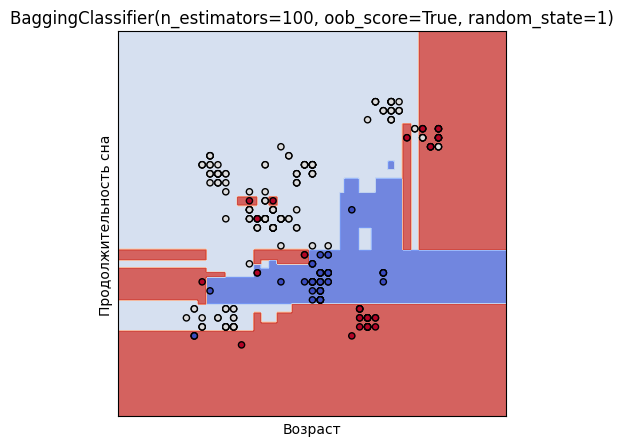

In [149]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
import numpy as np

X = X_train_classification[['age', 'sleep_duration']].values
y = y_train_classification.values

def make_meshgrid(x, y, h=.02):
    """Создание сетки точек для графика."""
    x_min, x_max = x.min() - 1, x.max() + 1
    y_min, y_max = y.min() - 1, y.max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    return xx, yy

def plot_contours(ax, clf, xx, yy, **params):
    """Построение контуров для предсказаний классификатора."""
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    out = ax.contourf(xx, yy, Z, **params)
    return out

def plot_cl(clf):
    """Функция для построения графика классификации."""
    title = str(clf)
    clf.fit(X, y)
    fig, ax = plt.subplots(figsize=(5, 5))
    X0, X1 = X[:, 0], X[:, 1]
    xx, yy = make_meshgrid(X0, X1)
    plot_contours(ax, clf, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
    ax.scatter(X0, X1, c=y, cmap=plt.cm.coolwarm, s=20, edgecolors='k')
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_xlabel('Возраст')
    ax.set_ylabel('Продолжительность сна')
    ax.set_xticks(())
    ax.set_yticks(())
    ax.set_title(title)
    plt.show()

plot_cl(bagging_clf)


# Случайный лес

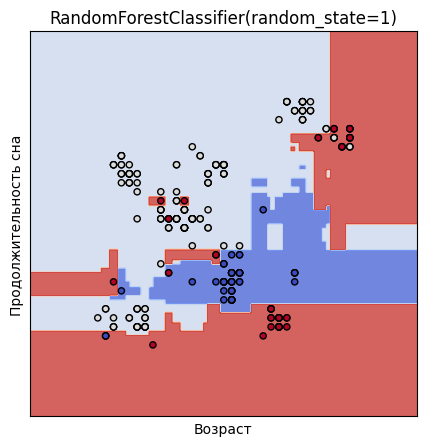

Точность классификации: 0.9466666666666667
Среднеквадратичная ошибка: 0.015114945574929782


In [150]:
# Классификация
rf_clf = RandomForestClassifier(n_estimators=100, random_state=1)
rf_clf.fit(X, y)

# Используем функцию plot_cl для визуализации результатов классификации
plot_cl(rf_clf)

rf_clf = RandomForestClassifier(n_estimators=100, random_state=1)
rf_clf.fit(X_train_classification, y_train_classification)

# Предсказания и метрика для классификации
y_pred_clf_rf = rf_clf.predict(X_test_classification)
accuracy = accuracy_score(y_test_classification, y_pred_clf_rf)

print(f"Точность классификации: {accuracy}")

# Регрессия
rf_reg = RandomForestRegressor(n_estimators=100, random_state=1)
rf_reg.fit(X_train_regression, y_train_regression)

# Предсказания и метрика для регрессии
y_pred_reg_rf = rf_reg.predict(X_test_regression)
mse = mean_squared_error(y_test_regression, y_pred_reg_rf)

print(f"Среднеквадратичная ошибка: {mse}")


# Сверхслучайные деревья

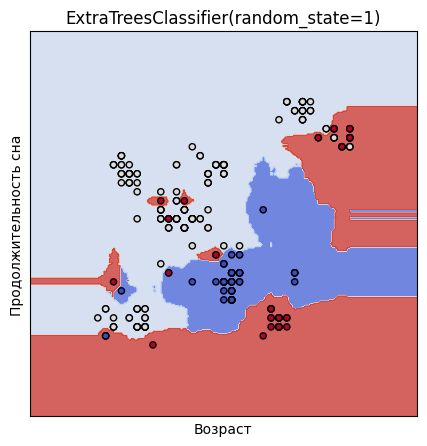

Точность классификации: 0.9333333333333333
Среднеквадратичная ошибка: 0.009240851094488816


In [151]:
# Классификация
et_clf = ExtraTreesClassifier(n_estimators=100, random_state=1)
et_clf.fit(X, y)

# Используем функцию plot_cl для визуализации результатов классификации
plot_cl(et_clf)


et_clf.fit(X_train_classification, y_train_classification)

# Предсказания и метрика для классификации
y_pred_clf_et = et_clf.predict(X_test_classification)
accuracy = accuracy_score(y_test_classification, y_pred_clf_et)

print(f"Точность классификации: {accuracy}")

# Регрессия
et_reg = ExtraTreesRegressor(n_estimators=100, random_state=1)
et_reg.fit(X_train_regression, y_train_regression)

# Предсказания и метрика для регрессии
y_pred_reg_et = et_reg.predict(X_test_regression)
mse = mean_squared_error(y_test_regression, y_pred_reg_et)

print(f"Среднеквадратичная ошибка: {mse}")


# AdaBoost

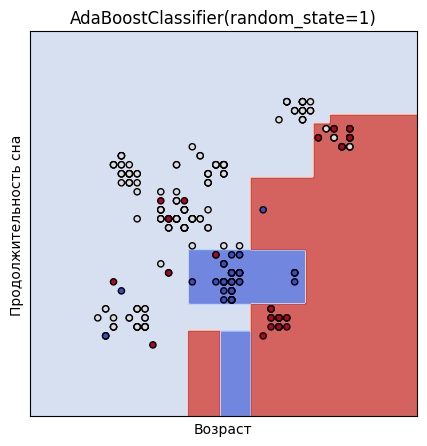

Точность классификации: 0.9333333333333333
Среднеквадратичная ошибка: 0.014240964719276154


In [152]:
# Классификация
ada_clf = AdaBoostClassifier(random_state=1)
ada_clf.fit(X, y)

# Используем функцию plot_cl для визуализации результатов классификации
plot_cl(ada_clf)


ada_clf.fit(X_train_classification, y_train_classification)

# Предсказания и метрика для классификации
y_pred_clf_ada = ada_clf.predict(X_test_classification)
accuracy = accuracy_score(y_test_classification, y_pred_clf_ada)

print(f"Точность классификации: {accuracy}")

# Регрессия
ada_reg = AdaBoostRegressor(random_state=1)
ada_reg.fit(X_train_regression, y_train_regression)

# Предсказания и метрика для регрессии
y_pred_reg_ada = ada_reg.predict(X_test_regression)
mse = mean_squared_error(y_test_regression, y_pred_reg_ada)

print(f"Среднеквадратичная ошибка: {mse}")


# Градиетный бустинг

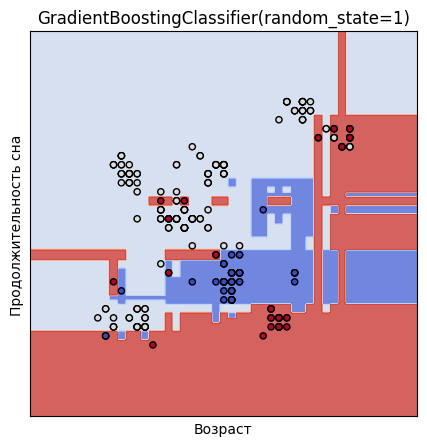

Точность классификации: 0.96
Среднеквадратичная ошибка: 0.0037038752519915692


In [153]:
# Классификация
gb_clf = GradientBoostingClassifier(random_state=1)
gb_clf.fit(X, y)

# Используем функцию plot_cl для визуализации результатов классификации
plot_cl(gb_clf)

gb_clf.fit(X_train_classification, y_train_classification)

# Предсказания и метрика для классификации
y_pred_clf_gb = gb_clf.predict(X_test_classification)
accuracy = accuracy_score(y_test_classification, y_pred_clf_gb)

print(f"Точность классификации: {accuracy}")

# Регрессия
gb_reg = GradientBoostingRegressor(random_state=1)
gb_reg.fit(X_train_regression, y_train_regression)

# Предсказания и метрика для регрессии
y_pred_reg_gb = gb_reg.predict(X_test_regression)
mse = mean_squared_error(y_test_regression, y_pred_reg_gb)

print(f"Среднеквадратичная ошибка: {mse}")


# Оцените качество моделей с помощью одной из подходящих для задачи метрик. Сравните качество полученных моделей.

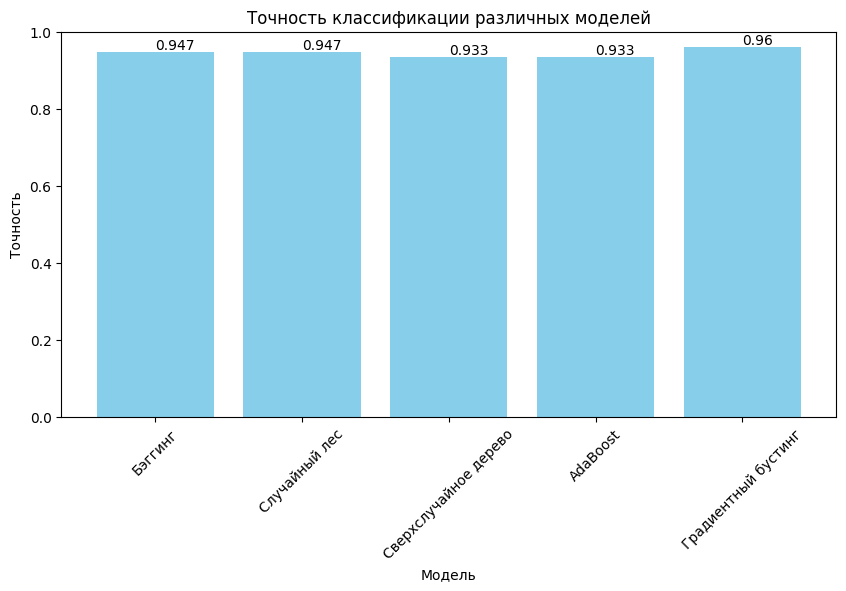

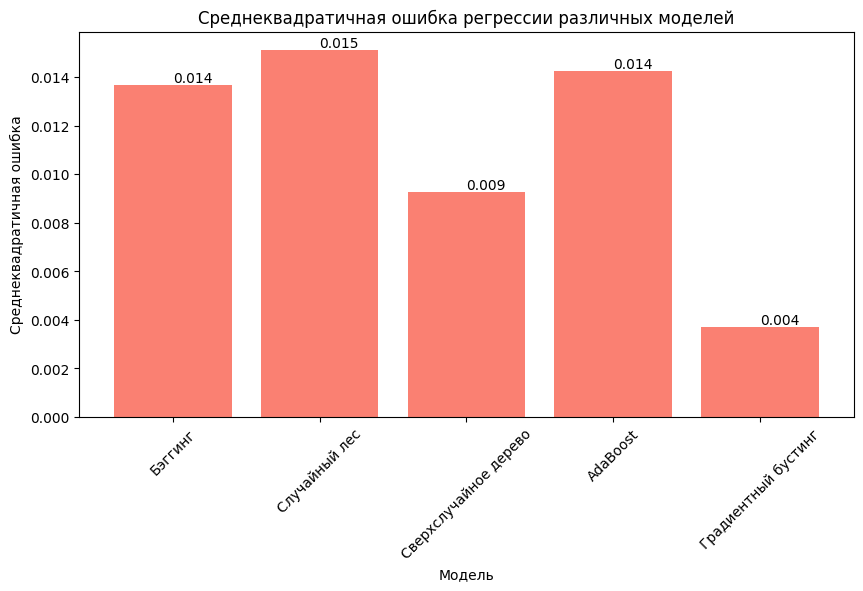

In [157]:
import matplotlib.pyplot as plt

# Данные для классификации
classification_models = ['Бэггинг', 'Случайный лес', 'Сверхслучайное дерево', 'AdaBoost', 'Градиентный бустинг']
classification_accuracies = [
    accuracy_score(y_test_classification, y_pred_classification),
    accuracy_score(y_test_classification, y_pred_clf_rf),
    accuracy_score(y_test_classification, y_pred_clf_et),
    accuracy_score(y_test_classification, y_pred_clf_ada),
    accuracy_score(y_test_classification, y_pred_clf_gb)
]

# Данные для регрессии
regression_models = ['Бэггинг', 'Случайный лес', 'Сверхслучайное дерево', 'AdaBoost', 'Градиентный бустинг']
regression_errors = [
    mean_squared_error(y_test_regression, y_pred_regression),
    mean_squared_error(y_test_regression, y_pred_reg_rf),
    mean_squared_error(y_test_regression, y_pred_reg_et),
    mean_squared_error(y_test_regression, y_pred_reg_ada),
    mean_squared_error(y_test_regression, y_pred_reg_gb)
]

# Построение графика для классификации
plt.figure(figsize=(10, 5))
bars = plt.bar(classification_models, classification_accuracies, color='skyblue')
plt.title('Точность классификации различных моделей')
plt.xlabel('Модель')
plt.ylabel('Точность')
plt.ylim(0, 1)
plt.xticks(rotation=45)

# Подписи точных значений на каждом столбце
for bar, accuracy in zip(bars, classification_accuracies):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(accuracy, 3), va='bottom') 

plt.show()

# Построение графика для регрессии
plt.figure(figsize=(10, 5))
bars = plt.bar(regression_models, regression_errors, color='salmon')
plt.title('Среднеквадратичная ошибка регрессии различных моделей')
plt.xlabel('Модель')
plt.ylabel('Среднеквадратичная ошибка')
plt.xticks(rotation=45)

# Подписи точных значений на каждом столбце
for bar, error in zip(bars, regression_errors):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(error, 3), va='bottom') 

plt.show()
